In [12]:
### import necessary packages
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
### import data and basic exploration

# read data from tsv 
data= pd.read_csv("./brca_metabric_clinical_data.tsv", sep="\t")

# check shape
print(data.shape)

# check columns
print(data.columns)

# check data types
print(data.dtypes)

# check for missing values
print(data.isnull().sum())

# see unique values for each column
for col in data.columns:
    print(f"Unique values in {col}: {data[col].unique()}")
    

(2509, 39)
Index(['Study ID', 'Patient ID', 'Sample ID', 'Age at Diagnosis',
       'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed',
       'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Cohort',
       'ER status measured by IHC', 'ER Status', 'Neoplasm Histologic Grade',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Overall Survival (Months)', 'Overall Survival Status', 'PR Status',
       'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status',
       'Number of Samples Per Patient', 'Sample Type', 'Sex',
       '3-Gene classifier subtype', 'TMB (nonsynonymous)', 'Tumor Size',
       'Tumor Stage', 'Patient's Vital Status'],
      dtype='str')
Study ID              

# Description of Features
| Feature | Description |
|---------|-------------|
|Study ID|"brca_metabric"|      
|Patient ID|Identifier to uniquely specify a patient|
|Sample ID|A unique sample identifier (matches patient ID)|
|Age at Diagnosis|Age at diagnosis in years|
|Type of Breast Surgery|"MASTECTOMY", "BREAST CONSERVING" or nan|
|Cancer Type|"Breast Cancer"|
|Cancer Type Detailed|'Breast Invasive Ductal Carcinoma','Breast Mixed Ductal and Lobular Carcinoma','Breast Invasive Lobular Carcinoma','Invasive Breast Carcinoma','Breast Invasive Mixed Mucinous Carcinoma','Breast Angiosarcoma','Breast', or 'Metaplastic Breast Cancer'|
|Cellularity|The proportion of the specimen that consists of tumour cells("High", "Medium", "Low", or nan)|
|Chemotherapy| Wether or not patient underwent chemo ("YES", "NO" or nan)|
|Pam50 + Claudin-low subtype| One method for classifying cancer subtypes ('claudin-low', 'LumA', 'LumB', 'Normal', nan, 'Her2', 'Basal', 'NC')|
|Cohort| Number 1-9 or nan|
|ER status measured by IHC|Estrogen-Receptor status measured by immunohistochemistry ("Positve", "Negative", or nan) * note the mispelling of positive|
|ER status|Estrogen-Receptor status ('Positive', 'Negative', or nan)|
|Neoplasm Histologic Grade|Numeric value to express the degree of abnormality of cancer cells, a measure of differentiation and aggressiveness. (1, 2, 3, or nan)|
|HER2 status measured by SNP6|HER2 status measured by SNP6 ("Positive", "Negative" or nan)|
|HER2 Status|HER2 status ("Positive", "Negative" or nan)|
|Tumor Other Histologic Subtype|Text to describe a tumor's histologic subtype or mixed diagnosis that is different from previously specified options. ('Ductal/NST','Mixed','Lobular', 'Tubular/ cribriform', 'Mucinous','Medullary','Other','Metaplastic', or nan)|
|Hormone Therapy|"Yes", "No" or nan|
|Inferred Menopausal State|"Pre", "Post" or nan|
|Integrative Cluster|One method for classifying cancer subtypes ('4ER+', '3', '9', '7', '4ER-', nan, '5', '8', '10', '1', '2', '6'|
|Primary Tumor Laterality|Side of the body primarily affected('Right', 'Left', nan)|
|Lymph nodes examined positive|Number of cancerous lymph nodes found |
|Mutation Count|Number of mutations found|
|Nottingham prognostic index| Estimates prognosis based on lymph node and histologic grade, lower index means better prognosis|
|Oncotree Code||
|Overall Survival (Months)||
|Overall Survival Status||
|PR Status||
|Radio Therapy||
|Relapse Free Status (Months)||
|Relapse Free Status||
|Number of Samples Per Patient||
|Sample Type||
|Sex|"Female"|
|3-Gene classifier subtype||
|TMB (nonsynonymous)||
|Tumor Size||
|Tumor Stage||
|Patient's Vital Status||


In [ ]:
### see how many non NaN mismatches are between ER by IHC and ER status
mismatch_count=0
for index, row in data.iterrows():
    if row["ER Status"] != row["ER status measured by IHC"]:
        if not (row["ER Status"]=="Positive" and row["ER status measured by IHC"]=="Positve"):
            if not (pd.isna(row["ER Status"]) or pd.isna(row["ER status measured by IHC"])):
                mismatch_count+=1

print(mismatch_count)

128


# Baseline features to include
Age at diagnosis  
Cancer Type Detailed  
Inferred Menopausal State  
Tumor Size   
Lymph Nodes Examined Positive   


# Different classification methods to test
3-gene classifier  
Pam50 + Claudin-low subtype  
Integrative clusters


# Outcomes to predict
Overall Survival (months)
Patient's Vital Status

In [4]:
### remove non-selected features

# list of featires to keep
keep_columns=["Age at Diagnosis", 
              "Cancer Type Detailed", 
              "Inferred Menopausal State", 
              "Tumor Size", 
              "Tumor Stage", 
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster",
              "Overall Survival (Months)",
              "Patient's Vital Status"]

# 
keep_data = data[keep_columns].copy()

print(keep_data.columns)

Index(['Age at Diagnosis', 'Cancer Type Detailed', 'Inferred Menopausal State',
       'Tumor Size', 'Tumor Stage', 'Lymph nodes examined positive',
       '3-Gene classifier subtype', 'Pam50 + Claudin-low subtype',
       'Integrative Cluster', 'Overall Survival (Months)',
       'Patient's Vital Status'],
      dtype='str')


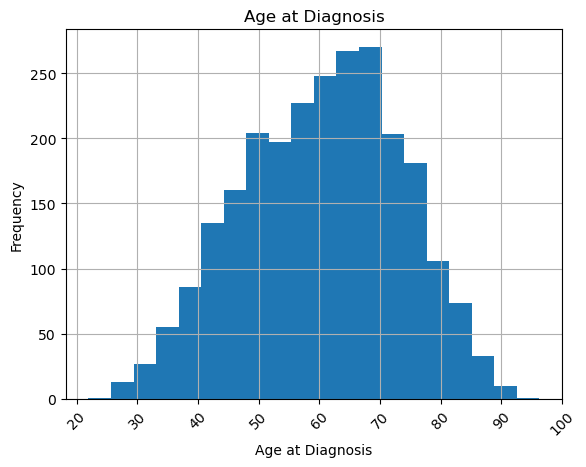

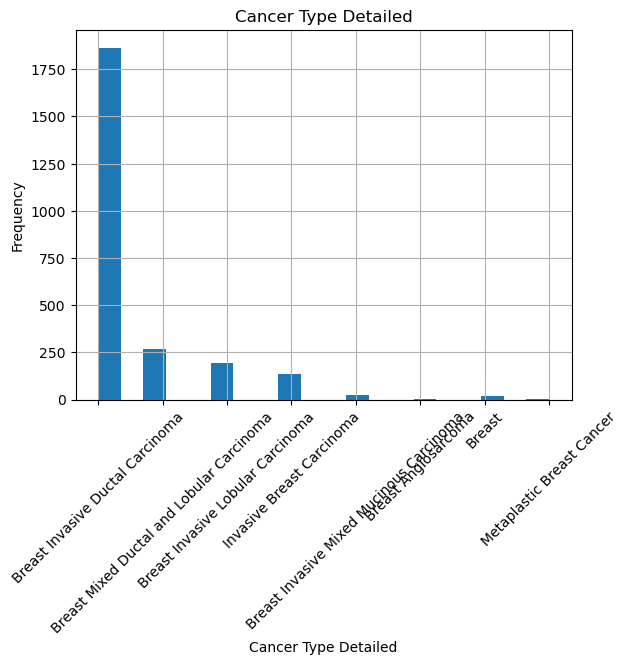

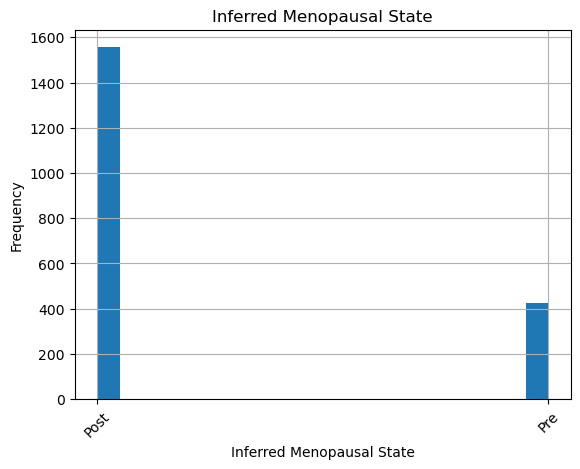

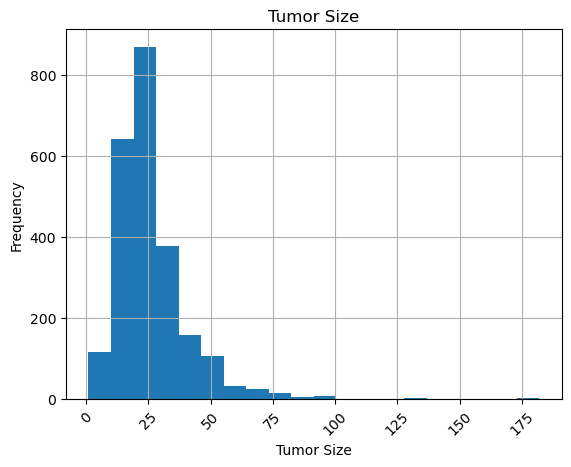

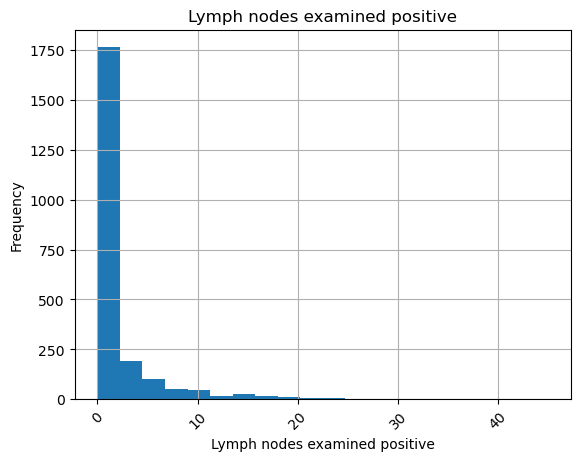

In [14]:
# get histograms for each baseline predictor
import matplotlib.pyplot as plt

baseline_predictors= ["Age at Diagnosis",
                      "Cancer Type Detailed",
                      "Inferred Menopausal State",
                      "Tumor Size",
                      "Lymph nodes examined positive"]

data = keep_data.dropna(subset=["Overall Survival (Months)"])

for column in baseline_predictors:
    keep_data[column].hist(bins=20)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()
    

In [29]:
# get summary stats
for column in baseline_predictors:
    print(f"\n{'='*40}")
    print(column)

    if pd.api.types.is_numeric_dtype(keep_data[column]):
        print("Mean:", keep_data[column].mean())
        print("Median:", keep_data[column].median())
        print("Mode:", keep_data[column].mode().tolist())
        print("SD:", keep_data[column].std())
        print("Range:", keep_data[column].max() - keep_data[column].min())
        print("Number of NaNs:", keep_data[column].isna().sum())
    
    else: 
        print("Mode:", keep_data[column].mode().tolist())
        print("Number of NaNs:", keep_data[column].isna().sum())
    
    
    


Age at Diagnosis
Mean: 61.086986370519945
Median: 61.81
Mode: [49.61]
SD: 12.949709932179637
Range: 74.36000000000001
Number of NaNs: 0

Cancer Type Detailed
Mode: ['Breast Invasive Ductal Carcinoma']
Number of NaNs: 0

Inferred Menopausal State
Mode: ['Post']
Number of NaNs: 1

Tumor Size
Mean: 26.275580562659847
Median: 23.0
Mode: [20.0]
SD: 15.379858261084356
Range: 181.0
Number of NaNs: 26

Lymph nodes examined positive
Mean: 2.0010498687664042
Median: 0.0
Mode: [0.0]
SD: 4.079179424780137
Range: 45.0
Number of NaNs: 76


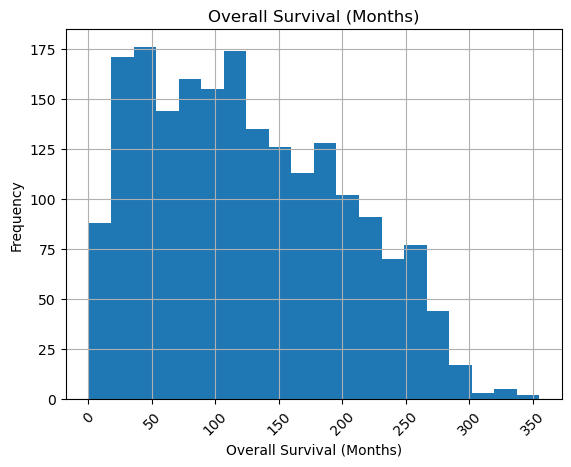

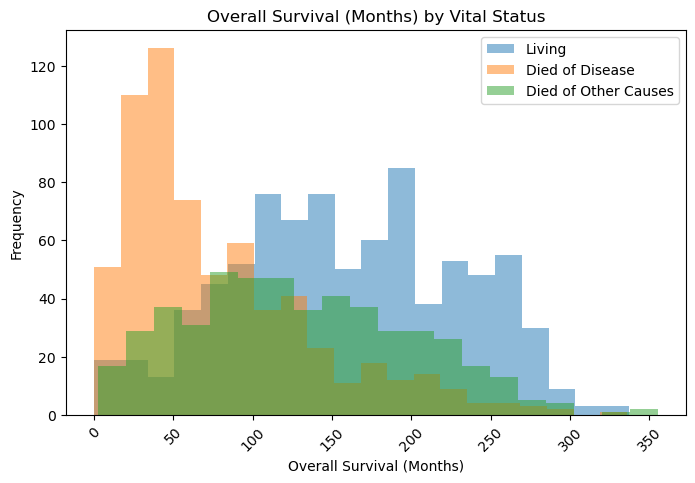

In [30]:

keep_data["Overall Survival (Months)"].hist(bins=20)
plt.title("Overall Survival (Months)")
plt.xlabel("Overall Survival (Months)")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

groups = keep_data["Patient's Vital Status"].dropna().unique()

plt.figure(figsize=(8, 5))

for status in groups:
    subset = keep_data[keep_data["Patient's Vital Status"] == status]
    plt.hist(
        subset["Overall Survival (Months)"],
        bins=20,
        alpha=0.5,
        label=status
    )

plt.title("Overall Survival (Months) by Vital Status")
plt.xlabel("Overall Survival (Months)")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [31]:
# for the patients that have overall survival in months, find the number of patients with missing data in each column in keep_columns
survival_data = keep_data[keep_data["Overall Survival (Months)"].notna()]
for column in keep_columns:
    missing_count = survival_data[column].isna().sum()
    print(f"Missing values in {column}: {missing_count}")

# print the number of patients with overall survival in months
print(f"Number of patients with overall survival in months: {survival_data.shape[0]}")
    


Missing values in Age at Diagnosis: 0
Missing values in Cancer Type Detailed: 0
Missing values in Inferred Menopausal State: 1
Missing values in Tumor Size: 26
Missing values in Tumor Stage: 515
Missing values in Lymph nodes examined positive: 76
Missing values in 3-Gene classifier subtype: 217
Missing values in Pam50 + Claudin-low subtype: 1
Missing values in Integrative Cluster: 1
Missing values in Overall Survival (Months): 0
Missing values in Patient's Vital Status: 1
Number of patients with overall survival in months: 1981


In [16]:
### Version 1a
### discretize overall survival (months) into 3 equal grouops
data["Target1a"], bins = pd.qcut(data["Overall Survival (Months)"],
                                q=3,
                                labels=["0-6.73 years", 
                                        "6.73-13.17 years", 
                                        "13.17+ years"],
                                retbins=True)


print(bins)


[  0.          80.73333333 158.03333333 355.2       ]


In [15]:
### Version 1b
### discretize overall survival (months) into 3 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=156:
        data.loc[index, "Target1b"] = "13+ years"
    elif row["Overall Survival (Months)"]>=84:
        data.loc[index, "Target1b"] = "7-13 years"
    else:
        data.loc[index, "Target1b"] = "<7 years"


In [17]:
### Version 2a
### discretize overall survival (months) into 4 equal groups
data["Target2a"], bins = pd.qcut(data["Overall Survival (Months)"],
                                q=4,
                                labels=["0-5.07 years", 
                                        "5.07-9.71 years", 
                                        "9.71-15.43 years", 
                                        "15.43+ years"],
                                retbins=True)


print(bins)


[  0.          60.86666667 116.46666667 185.13333333 355.2       ]


In [18]:
### Version 2b
### discretize overall survival (months) into 4 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=180:
        data.loc[index, "Target2b"] = "15+ years"
    elif row["Overall Survival (Months)"]>=120:
        data.loc[index, "Target2b"] = "10-15 years"
    elif row["Overall Survival (Months)"]>=60:
        data.loc[index, "Target2b"] = "5-10 years"
    else:
        data.loc[index, "Target2b"] = "<5 years"

In [19]:
### Version 3a
### discretize overall survival (months) into 5 equal groups
data["Target3a"], bins = pd.qcut(data["Overall Survival (Months)"],
                                q=5,
                                labels=["0-4.11 years", 
                                        "4.11-7.89 years", 
                                        "7.89-11.69 years", 
                                        "11.69-16.47 years",
                                        "16.47+ years"],
                                retbins=True)


print(bins)

[  0.          49.3         94.7        140.23333333 197.66666667
 355.2       ]


In [20]:
### Version 3b
### discretize overall survival (months) into 5 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=198.5:
        data.loc[index, "Target3b"] = "16.5+ years"
    elif row["Overall Survival (Months)"]>=144:
        data.loc[index, "Target3b"] = "12-16.5 years"
    elif row["Overall Survival (Months)"]>=96:
        data.loc[index, "Target3b"] = "8-12 years"
    elif row["Overall Survival (Months)"]>=48:
        data.loc[index, "Target3b"] = "4-7 years"
    else:
        data.loc[index, "Target3b"] = "<4 years"

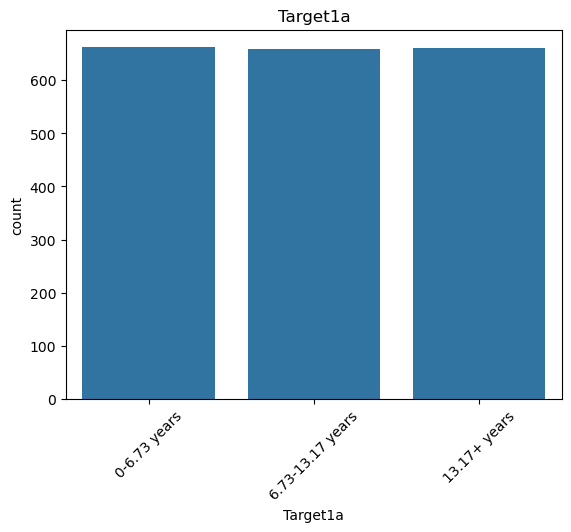

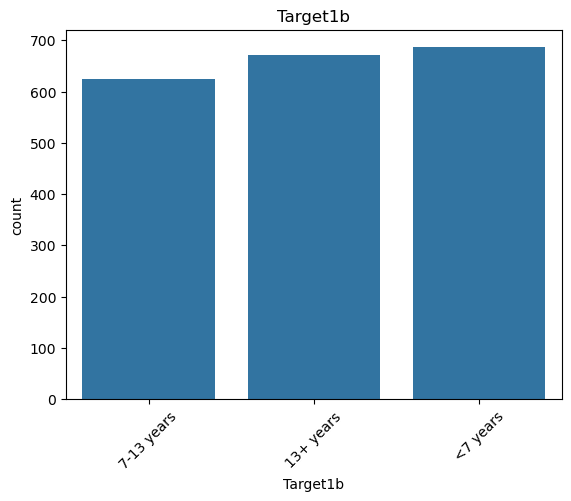

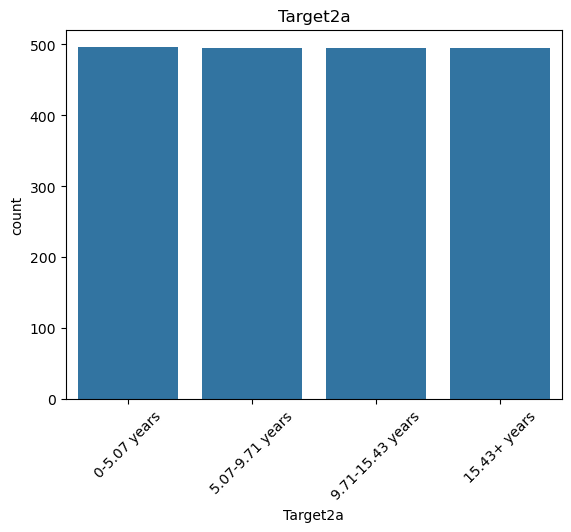

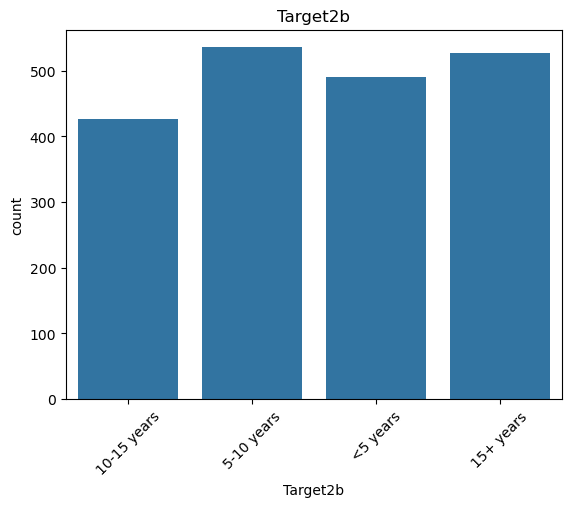

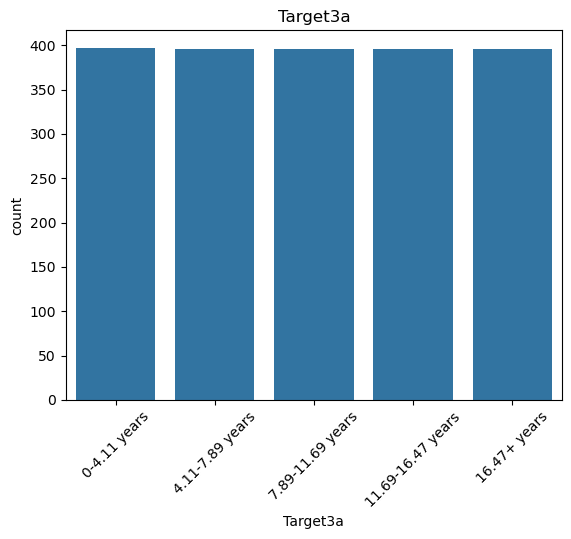

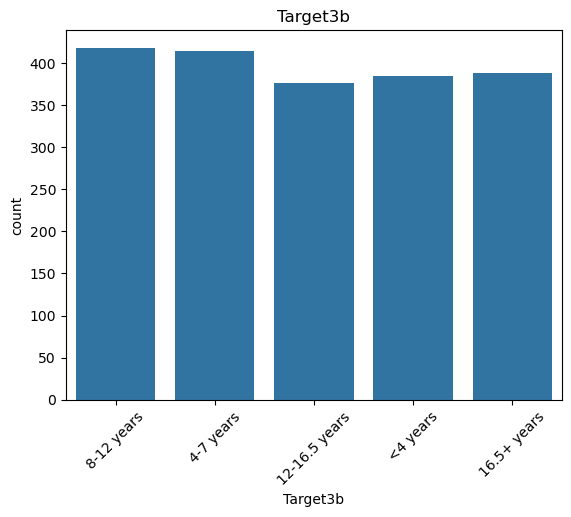

In [21]:
### check distributions
import seaborn as sns

# Target1a
sns.countplot(data, x="Target1a")
plt.title('Target1a')
plt.xticks(rotation=45)
plt.show()

# Target1b
sns.countplot(data, x="Target1b")
plt.title('Target1b')
plt.xticks(rotation=45)
plt.show()

# Target2a
sns.countplot(data, x="Target2a")
plt.title('Target2a')
plt.xticks(rotation=45)
plt.show()

# Target2b
sns.countplot(data, x="Target2b")
plt.title('Target2b')
plt.xticks(rotation=45)
plt.show()

# Target3a
sns.countplot(data, x="Target3a")
plt.title('Target3a')
plt.xticks(rotation=45)
plt.show()

# Target3b
sns.countplot(data, x="Target3b")
plt.title('Target3b')
plt.xticks(rotation=45)
plt.show()

In [32]:
# remove sapmeles where Overall Survival is na
keep_data = keep_data.dropna(subset=["Overall Survival (Months)"])

# categorizing survival duration
for index, row in keep_data.iterrows():
    if row["Overall Survival (Months)"]>=240: # 20+ years
        keep_data.loc[index, "Survival Duration"] = "20+ years"
    elif row["Overall Survival (Months)"]>=180: # 15-20 years
        keep_data.loc[index, "Survival Duration"] = "15-20 years"
    elif row["Overall Survival (Months)"]>=120: # 10-15 years
        keep_data.loc[index, "Survival Duration"] = "10-15 years"
    elif row["Overall Survival (Months)"]>=72: # 7-10 years
        keep_data.loc[index, "Survival Duration"] = "7-10 years"
    elif row["Overall Survival (Months)"]>=48: # 4-7 years
        keep_data.loc[index, "Survival Duration"] = "4-7 years"
    elif row["Overall Survival (Months)"]>=24: # 2-4 years
        keep_data.loc[index, "Survival Duration"] = "2-4 years"
    else:
        keep_data.loc[index, "Survival Duration"] = "<2 years"

print(keep_data)

      Age at Diagnosis                       Cancer Type Detailed  \
0                75.65           Breast Invasive Ductal Carcinoma   
1                43.19           Breast Invasive Ductal Carcinoma   
2                48.87           Breast Invasive Ductal Carcinoma   
3                47.68  Breast Mixed Ductal and Lobular Carcinoma   
4                76.97  Breast Mixed Ductal and Lobular Carcinoma   
...                ...                                        ...   
1980             43.10          Breast Invasive Lobular Carcinoma   
1981             42.88           Breast Invasive Ductal Carcinoma   
1982             62.90           Breast Invasive Ductal Carcinoma   
1983             61.16           Breast Invasive Ductal Carcinoma   
1984             60.02           Breast Invasive Ductal Carcinoma   

     Inferred Menopausal State  Tumor Size  Tumor Stage  \
0                         Post        22.0          2.0   
1                          Pre        10.0          1

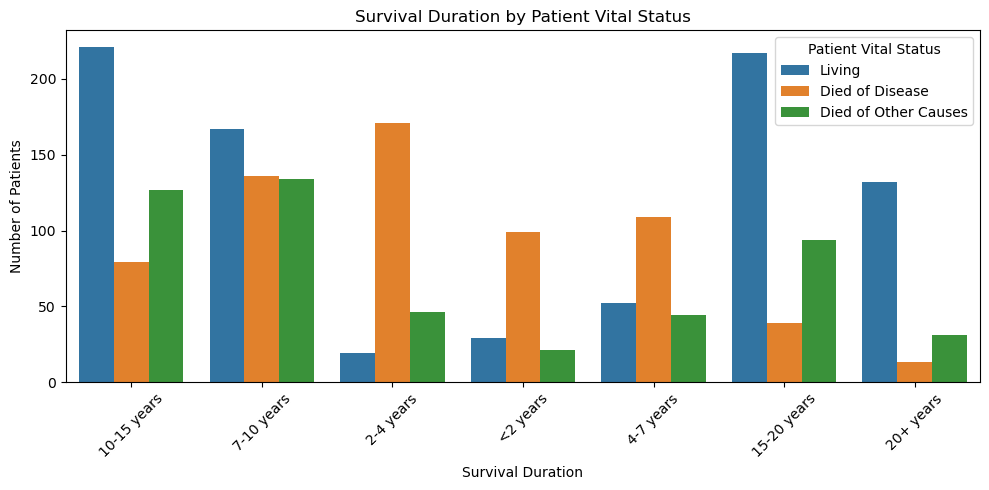

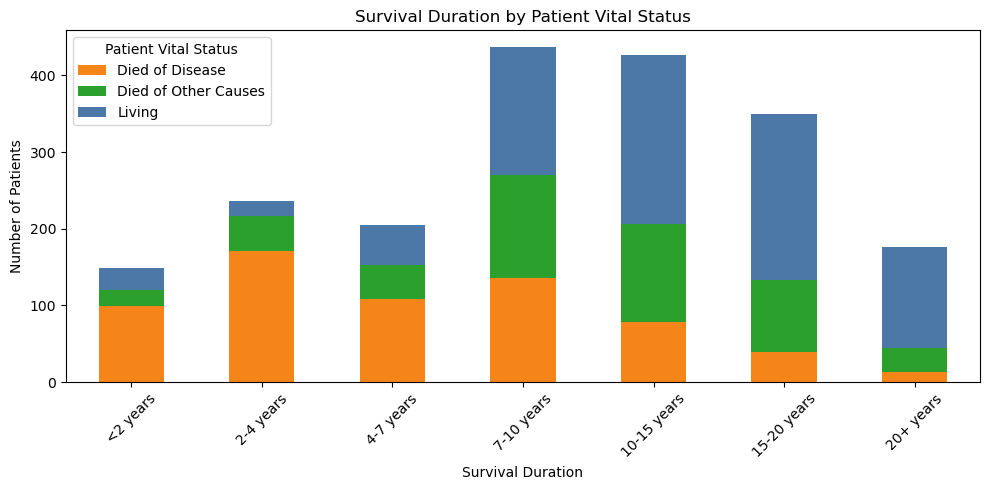

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.countplot(
    data=keep_data,
    x="Survival Duration",
    hue="Patient's Vital Status"
)

plt.title("Survival Duration by Patient Vital Status")
plt.xlabel("Survival Duration")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.legend(title="Patient Vital Status")
plt.tight_layout()
plt.show()

order = [
    "<2 years",
    "2-4 years",
    "4-7 years",
    "7-10 years",
    "10-15 years",
    "15-20 years",
    "20+ years"
]

# Count patients by Survival Duration and Vital Status
counts = pd.crosstab(
    keep_data["Survival Duration"],
    keep_data["Patient's Vital Status"]
)

counts = counts.reindex(order)

counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color = ["#F58518", "#2ca02c", "#4C78A8"]
)


plt.title("Survival Duration by Patient Vital Status")
plt.xlabel("Survival Duration")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.legend(title="Patient Vital Status")
plt.tight_layout()
plt.show()